# F04_JDSSS_phase_yr.ipynb
Figure 4: JDSSS snow progression phases per year


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
from pathlib import Path
import xarray as xr
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata
import load_data as load_data
import melt_phases as melt_phases
import fig_2a as fig_2a


In [4]:
import importlib
importlib.reload(metadata)
importlib.reload(load_data)
importlib.reload(melt_phases)
importlib.reload(fig_2a)


<module 'fig_2a' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/figures/../scripts/fig_2a.py'>

# Inputs

In [5]:
year = 2017

# Load Data

## Metadata

### point locations

#### CUES

In [6]:
importlib.reload(metadata)
# load config
cues_cfg = metadata.load_yaml(Path(f"../../configs/CUES.yaml"))
# load point geometry
cues_lat,cues_lon,cues_x,cues_y,cues_crs = metadata.get_point_geography(cues_cfg,'cues')
# load snowmodel filepath
sm_cues_OBS_swe_fpath = metadata.get_cuesOBS_fpath(cues_cfg,'swe')
sm_cues_OBS_sweMelt_fpath = metadata.get_cuesOBS_fpath(cues_cfg,'swe_melt')


### polygon geometries

In [7]:
importlib.reload(metadata)
# cues
cues_geog_fpath,aso_crs = metadata.get_shapefile_fpath(cues_cfg,"shapefile_fpath","zoom_2")
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
_,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")
# read shapefile
## cues
cues_geog_gdf = gpd.read_file(cues_geog_fpath)
cues_proj_gdf = cues_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## time series

### SWE

#### SnowModel

In [8]:
sm_cues_optimized_fpath = cues_cfg["snowmodel_fpath"]["optimized"]
sm_cues_biased_fpath = cues_cfg["snowmodel_fpath"]["biased"]


In [9]:
importlib.reload(load_data)
cues_sm_biased_swe_da = load_data.load_multidirectory_snowmodel_output(sm_cues_biased_fpath)
cues_sm_optimized_swe_da = load_data.load_multidirectory_snowmodel_output(sm_cues_optimized_fpath)


wy_2013-2022
wy_2013-2022
wy_2024
wy_2023


#### CUES

In [10]:
importlib.reload(load_data)
cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df = load_data.load_cues_OBS_SWE(sm_cues_OBS_swe_fpath)
cues_obs_swe_all_df = pd.concat([cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df])
cues_obs_swe_all_df.drop(columns = ['water_year'],inplace = True)
cues_obs_swe_all_df['DateTime'] = pd.to_datetime(cues_obs_swe_all_df['DateTime'])
cues_obs_swe_all_df.rename(columns = {'DateTime':'time',
                                      'SWE':'swed'},inplace = True)
cues_swe_ds = cues_obs_swe_all_df.set_index('time').to_xarray()
cues_swe_m_ds = (cues_swe_ds['swed'] / 1000).to_dataset(name = 'swed')
cues_swe_m_ds

<xarray.Dataset> Size: 86kB
Dimensions:  (time: 5367)
Coordinates:
  * time     (time) datetime64[ns] 43kB 2010-10-01 2010-10-02 ... 2025-06-30
Data variables:
    swed     (time) float64 43kB nan nan nan nan ... 0.001696 0.001404 0.001571

## Point Data

### SWE-Melt

In [11]:
importlib.reload(load_data)
df_lys = load_data.load_cues_OBS_SWE_melt(sm_cues_OBS_sweMelt_fpath)

### TAIR

In [12]:
ds_temp = xr.open_dataset('../../data/cues/cues/cues_2015_2025.nc')[['air_temperature','air_temperature_data_flag']]
ds_temp_day = ds_temp.resample(datetime='1D').mean()

### S-1 Backscatter

In [13]:
importlib.reload(load_data)
sentinel_cues_100m_2017 = load_data.load_sentinel_backscatter(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

idy_cues,idx_cues = load_data.sm_intersect_rectilinear(sentinel_cues_100m_2017.y.values,sentinel_cues_100m_2017.x.values,cues_y,cues_x)


### S-1 Reference Scene

In [14]:
importlib.reload(load_data)
sentinel_cues_reference_2017 = load_data.load_sentinel_reference(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                                                                  )


### SnowModel

#### Biased

In [15]:
importlib.reload(load_data)

sm_point_biased_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)


#### Optimized

In [16]:
importlib.reload(load_data)

sm_point_optimized_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)


## Melt Phases

### SnowModel

In [17]:
importlib.reload(melt_phases)

water_thresh_surface_ = 0.0035
water_thresh_internal_ = 0.0001
min_runoff_rate_ = 0.001  # 1 mm cumulative runoff in forward window
output_merge_dry_hours_ = 48
ripen_gap_days_ = 7

# --- Biased ---
ph_rv_biased_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

# --- Optimized ---
ph_rv_optimized_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)


### S-1

#### VV (Nagler 1996)

In [18]:
importlib.reload(melt_phases)

cfg = melt_phases.MarinS1VVCfg(min_stability_days=28,
                              max_group_spread_days=28,
                              max_am_pm_mismatch_days=28
                              )

vv_out_2017 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2017, sentinel_cues_reference_2017, idy_cues, idx_cues, year, cfg)


#### Weighted Combination (Nagler 2016)

In [19]:
import importlib
import sys


# Force complete reimport of melt_phases module
for mod in list(sys.modules.keys()):
    if 'melt_phases' in mod:
        del sys.modules[mod]

import melt_phases
importlib.reload(melt_phases)

if year == 2017:
    path_2017 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}{year}/melt_thresh_following_ref/data/datasets/' # using current year because previous year was NaN
else:
    path_2017 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}{year}/melt_thresh/data/datasets/'
    
# path_2017 = '/glade/derecho/scratch/rossamower/snow/snowmodel/school/uw/cues/data/sentinel/cues/100_m/2017/melt_thresh/data/datasets'
cfg_marin = melt_phases.MarinS1VVCfg(
    tau_db=-2.0,
    min_stability_days=28,
    max_group_spread_days=28,
    max_am_pm_mismatch_days=28,
)

cfg_w = melt_phases.WeightedMinimaCfg(
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
    cfg_marin=cfg_marin,
)

weighted_out_2017 = melt_phases.run_s1_rc_minima_year(path_2017, cues_y, cues_x, year, cfg_w)


## weighted time series

In [20]:
# import plotting as plotting

# ts = melt_phases.build_point_timeseries_all_orbits_from_files(
#     path_2017, cues_y, cues_x,
#     orbits=(64, 137, 144),
#     k=0.5, theta1=20, theta2=45,
#     wet_thresh_db=-2.0,
# )

# plotting.plot_orbit_timeseries(ts, wet_thresh_db=-2.0, title="CUES 2017 weighted wet detection per orbit")

## Comparison - Simplified Data

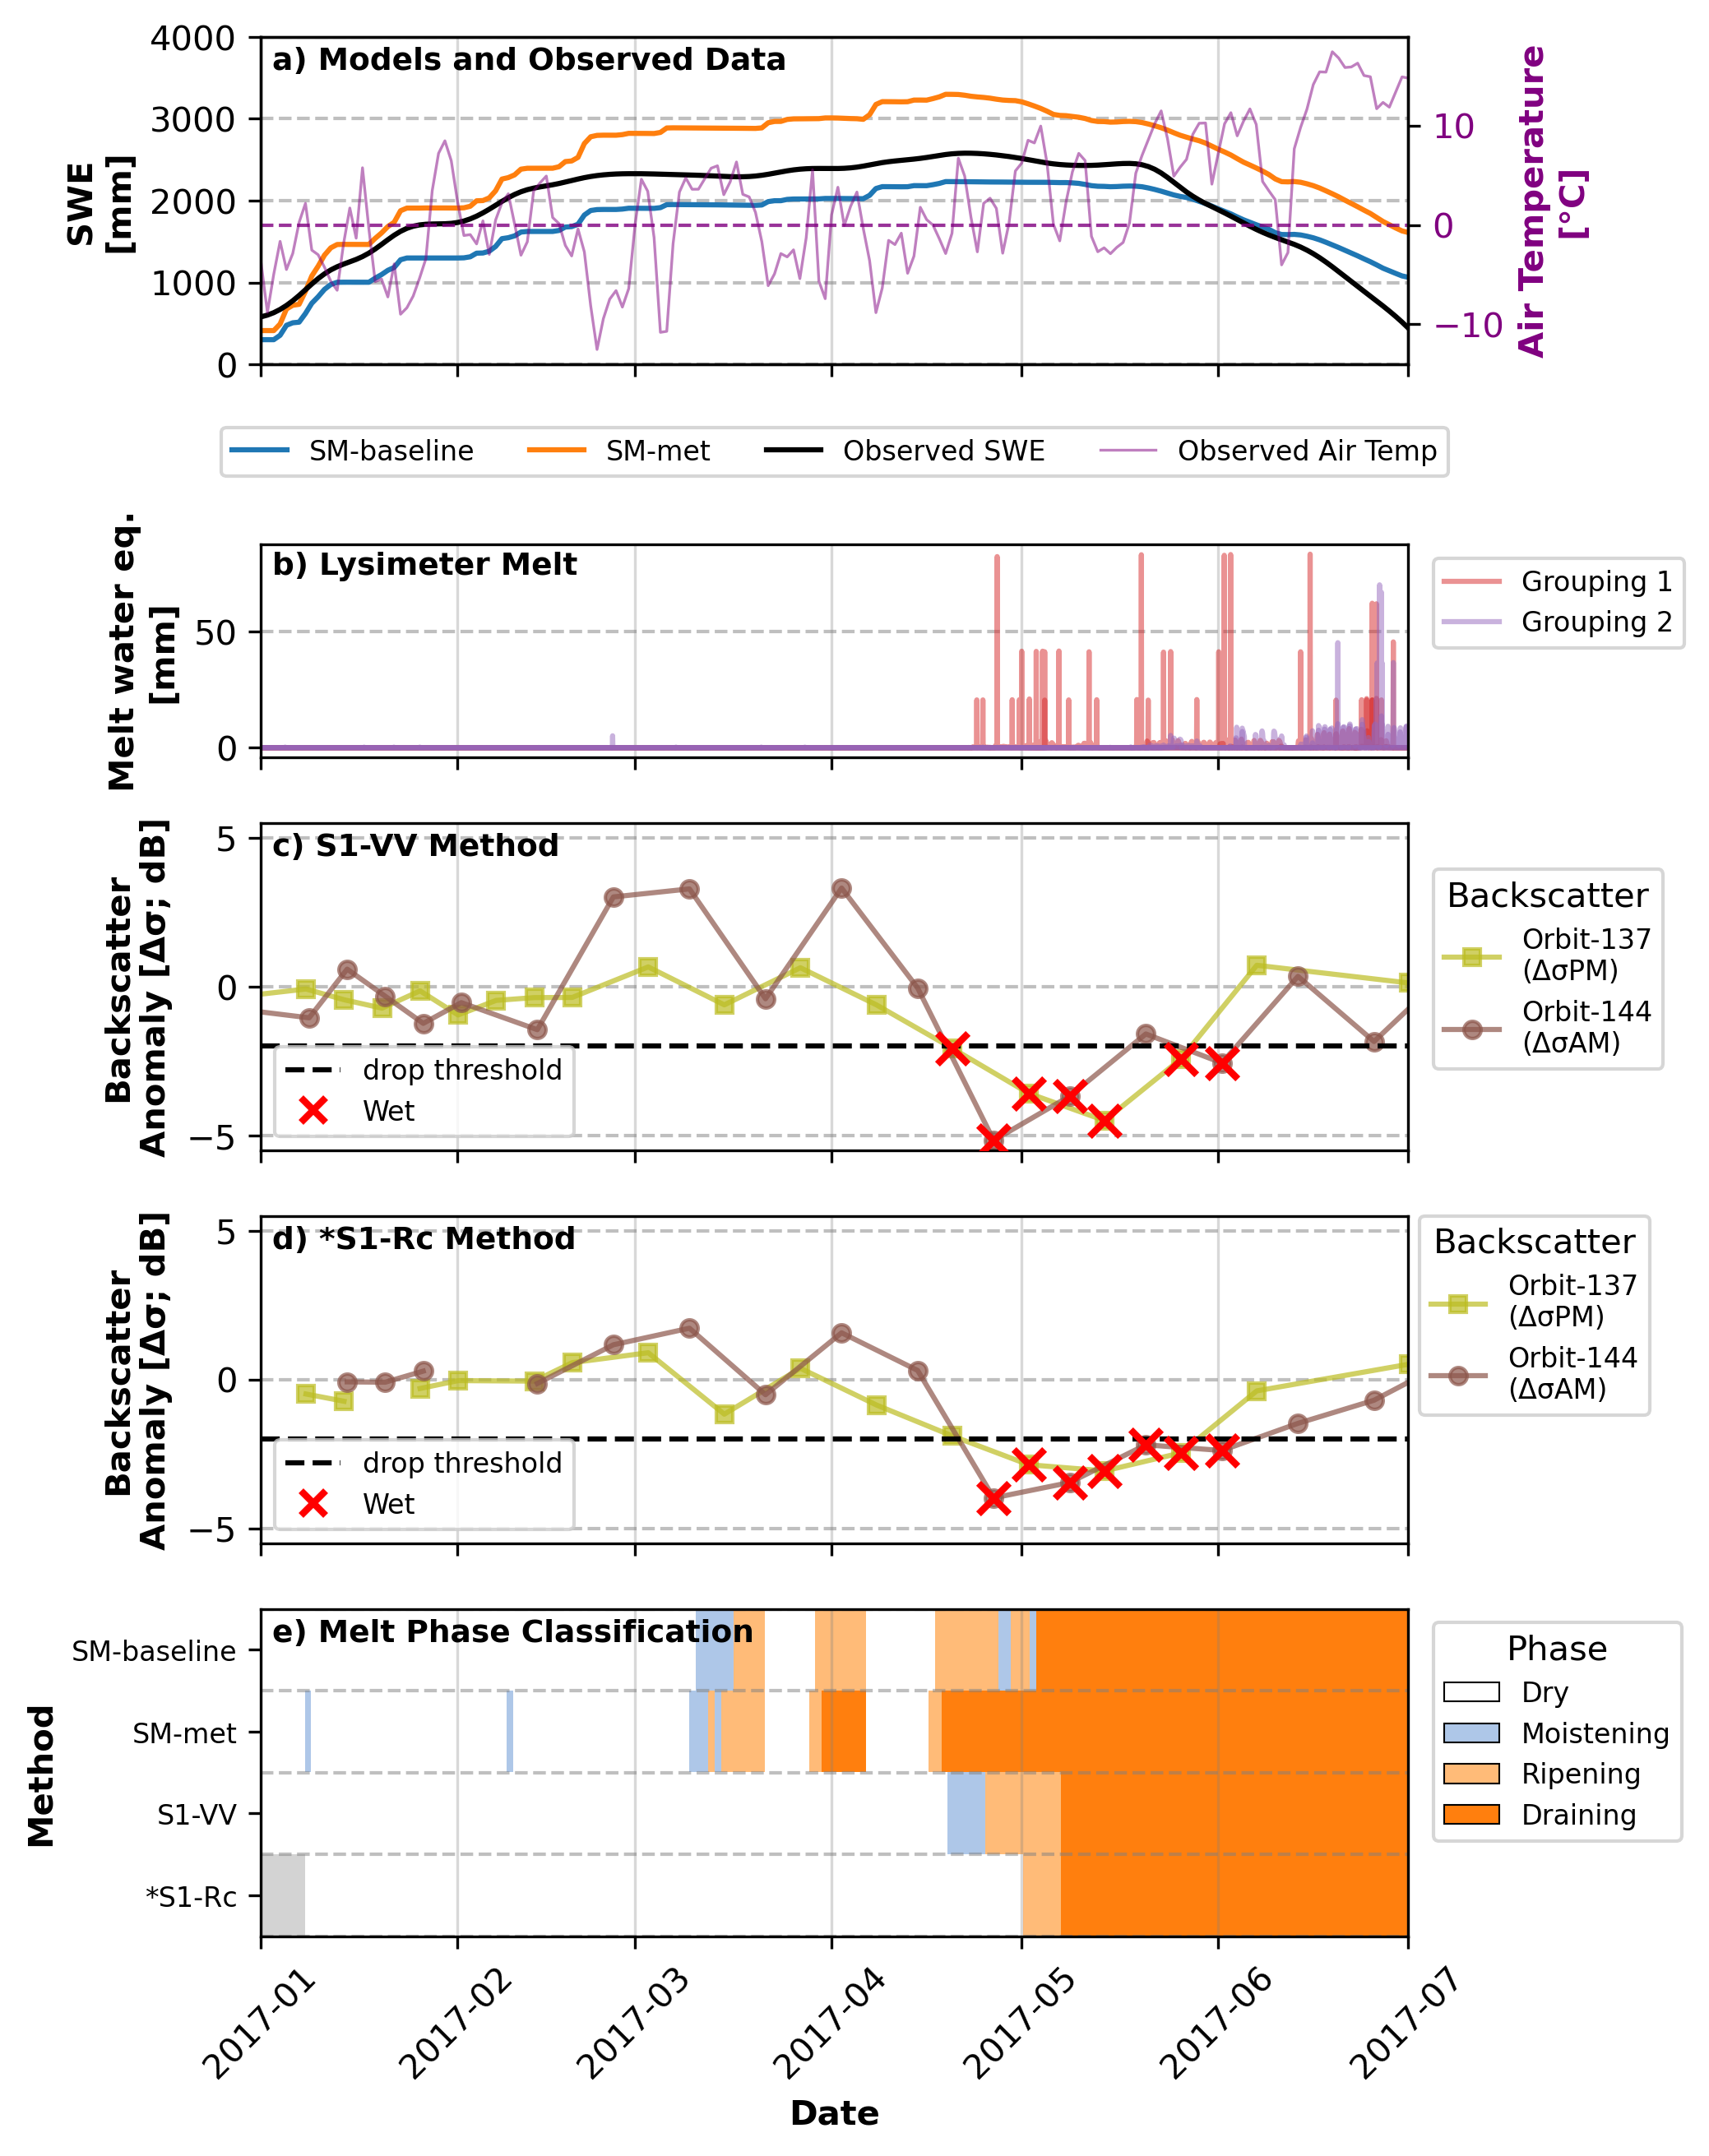

In [21]:
importlib.reload(melt_phases)
importlib.reload(fig_2a)



fig,ax = plt.subplots(5,1,sharex = True,figsize = (6,10),dpi = 300)


# Position ax[1] so the whitespace above it (below the ax[0] legend) and
# below it (above ax[2]) are both equal to the normal inter-subplot gap.
#
# The ax[0] legend is anchored at bbox_to_anchor=(0.5, -0.15), i.e. its
# top sits at ax[0].y0 - 0.15 * ax[0].height in figure coords.  We treat
# that as the upper boundary of the available space for ax[1].
_p0  = ax[0].get_position()
_p2  = ax[2].get_position()
_p3  = ax[3].get_position()

_gap        = _p2.y0 - (_p3.y0 + _p3.height)   # normal inter-subplot gap
_legend_top = _p0.y0 - 0.15 * _p0.height        # legend anchor (upper edge of legend box)
# The legend text extends ~_gap below its anchor, so legend_bottom ~ _legend_top - _gap.
# Reserve one more _gap between legend bottom and ax[1] top for visible clearance.
_ax1_top  = _legend_top - 2 * _gap              # _gap for legend height + _gap clearance
_ax1_bot  = _p2.y0 + _p2.height + _gap          # ax[2] top + one normal gap
_h1       = _ax1_top - _ax1_bot

ax[1].set_position([_p2.x0, _ax1_bot, _p2.width, max(_h1, 0.01)])


fig_2a.plot_snowmelt_phase_comp(year,
                         cues_sm_biased_swe_da,
                         None,
                         cues_sm_optimized_swe_da,
                         cues_obs_swe_NO_qa_df,
                         cues_obs_swe_qa_df,
                         start_date=f"{year}-01-01",
                         end_date=f"{year}-07-01",
                         ax=ax[0],
                         ds_temp_day=ds_temp_day,
                         plotTitle = False,
                         plotInsetTitle = True,
                         ymax_ = 4000,
                         )

fig_2a.plot_lysimeter(year,
               df_lys,
               start_date=f"{year}-01-01",
               end_date=f"{year}-07-01",
               ax=ax[1],
               plotTitle = False,
               plotInsetTitle = True,
               ) 

phases = fig_2a.make_panel_c_daily(
    ph_sm_biased=ph_rv_biased_2017,
    ph_sm_corrected=None,
    ph_sm_biased_wt=None,
    ph_sm_optimized=ph_rv_optimized_2017,
    ph_s1=vv_out_2017,
    ph_s1_2=weighted_out_2017,
    start=f"{year}-01-01",
    end=f"{year}-07-01",
    method_labels={
        "SM biased": "SM-baseline",
        "SM optimized": "SM-met",
        "S1 method 1": "S1-VV",
        "S1 method 2": "*S1-Rc",
        },
    method_order=("SM biased","SM optimized", "S1 method 1", "S1 method 2"),
    ax=ax[4],
    plotTitle = False,
    plotInsetTitle = True,

    
)

# Plot VV Method snow identification (combined morning and afternoon)
fig_2a.plot_vv_snow_identification_combined(
    sentinel_bscatter=sentinel_cues_100m_2017,
    sentinel_reference=sentinel_cues_reference_2017,
    start_date=f"{year}-01-01",
    end_date=f"{year}-07-01",
    orbit_list = [137,144],
    # orbit_list = [64],
    ax=ax[2],
    idy=idy_cues,
    idx=idx_cues,
    title="c) S1-VV Method",
    plotTitle = False,
    plotInsetTitle = True,
    ymin_ = -5.5,
    ymax_ = 5.5
    
)



ts = melt_phases.build_point_timeseries_all_orbits_from_files(
    path_2017, cues_y, cues_x,
    orbits=(64, 137, 144),
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
)

fig_2a.plot_orbit_timeseries_subplot(ts, 
                        wet_thresh_db=-2.0, 
                        # orbit_lst=[64],
                        orbit_lst=[137,144],
                        ax=ax[3],
                        onlyRc=True,
                        title="d) *S1-Rc Method",
                        plotTitle = False,
                        plotInsetTitle = True,
                        ymin_ = -5.5,
                        ymax_ = 5.5,
                        )


plt.savefig('./pngs/F04_JDSSS_melt_phase_2017.png',dpi = 300,
    bbox_inches="tight",
    pad_inches=0.05)
